In [43]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import math as m

import typing

In [44]:
all_participants: pd.DataFrame = pd.read_csv('test_data.csv')

print(f"N participants: {all_participants.shape[0]}")

print(f"\nQuestions:")
print(all_participants.keys())

N participants: 60

Questions:
Index(['Unnamed: 0', 'Name',
       'Which institute are you located at?\n\nOf you are affiliated with multiple institutions please give details (e.g. Imperial College London but based at CERN)',
       'In which region are you based?',
       'How will you be attending the meeting?',
       'Which of these best describes your job title?',
       'How long have you worked on T2K?',
       'Do you want to be matched with an early career (EC) member?',
       'Which topics would you like to discuss with your buddy? [Your physics / research interests]',
       'Which topics would you like to discuss with your buddy? [Hobbies and other (non physics) interests - please provide any specific you want to be considered below]',
       'Which topics would you like to discuss with your buddy? [Outreach]',
       'Which topics would you like to discuss with your buddy? [Diversity, equity and inclusion initiatives]',
       'Which topics would you like to discuss with

Here define the multiple choice question grid

Will need to adapt this to your own survey

In [45]:

## the institute the person is located at
institute_question = 'Which institute are you located at?\n\nOf you are affiliated with multiple institutions please give details (e.g. Imperial College London but based at CERN)'

## how the person will be attending (remote or in-person)
attendance_mode_question = 'How will you be attending the meeting?'

## what career stage is the person
career_stage_question = 'Which of these best describes your job title?'

## which career stages are considered "early career"
ecr_stages = ["PHD student", "Masters student", "Postdoc"]

## whether the person wants to be matched with an ECR participant
early_carreer_member_question = 'Do you want to be matched with an early career (EC) member?'

## what region is the person based in?
region_question = 'In which region are you based?'

## list of questions in the multiple choice grid
multiple_choice_questions = [
    'Which topics would you like to discuss with your buddy? [Your physics / research interests]',
    'Which topics would you like to discuss with your buddy? [Hobbies and other (non physics) interests - please provide any specific you want to be considered below]',
    'Which topics would you like to discuss with your buddy? [Outreach]',
    'Which topics would you like to discuss with your buddy? [Diversity, equity and inclusion initiatives]',
    'Which topics would you like to discuss with your buddy? [Shared identity (marginalised person in STEM, from a particular background/location etc. - please share details below)]',
    'Which topics would you like to discuss with your buddy? [Current political situation surrounding science (funding, policies etc.)]',    
]

## map questions to short tag
question_tag_map = {
    multiple_choice_questions[0]: "physics",
    multiple_choice_questions[1]: "hobbies",
    multiple_choice_questions[2]: "outreach",
    multiple_choice_questions[3]: "DEI",
    multiple_choice_questions[4]: "shared identity",
    multiple_choice_questions[5]: "politics"
}

## the options for the multiple choice questions
options_dict = {
    "Do not want to talk about": 0,
    "Could talk about": 1,
    "Want to talk about": 2,
    "High priority to talk about": 3,
}

options = list(options_dict.keys())

## Create a function that defines the compatibility between two participants
May need to change this depending on your needs

Rationale is as follows:
 * If one person really doesn't want to talk about something ("Do not want to talk about") and the other really does ("High priority to talk about"), probably shouldn't match them
 * If someone answered "could talk about" then they are pretty neutral so can match with someone who either does or doesn't want to talk about that thing. Hence this doesn't affect the score negatively (or positively)
 * If both people really want to talk about something, matching them is highly prioritised
 * If both people don't want to talk about something, prioritise the match a bit, but not as much as a "positive hit" (both of them wanting to talk about) 
 * Matching someone who would like to talk about something and someone who doesn't is penalised somewhat but can be made up for by other matching interests


In [46]:
## "one sided" compatibility score 
## non symmetric, covers each possibility only once. i.e. only covers situation where
def compute_compatibility(person1: pd.Series, person2: pd.Series) -> float:

    score = 0.0

    ## Score categories (might want to tweak a bit):

    ## one high priority and one doesn't wat to talk about
    really_bad = -1e5

    ## one kinda wants to talk about, one doesn't
    bad = -2

    ## both don't want to talk about
    kinda_good = 1

    ## both want to talk about
    good = 2

    ## both really want to talk about
    really_good = 5


    for question in multiple_choice_questions:

        ## person1 doesn't want to talk about something
        if person1[question] == options[0]:

            ## if person1 Doesn't want to talk about this and person2 is high priority, don't match them
            if person2[question] == options[-1]:
                score += really_bad

            ## if both people don't want to talk about this, bump score a bit
            if person2[question] == options[0]:
                score += kinda_good

            ## if person1 doesnt want to talk about this and person 2 kinda does, penalise
            if person2[question] == options[2]:
                score += bad

        ## person1 would like to talk about thing
        if person1[question] == options[2]:

            ## person2 would not like to talk about, penalise
            if person2[question] == options[0]:
                score += bad

            ## person2 would also like to talk about thing
            if person2[question] == options[2]:
                score += good

            ## person2 would really like to talk about thing
            if person2[question] == options[-1]:
                # somewhere between good and really good
                score += (good + really_good) / 2.0

        ## person1 would really like to talk about thing
        if person1[question] == options[-1]:

            ## person2 would not like to talk about
            if person2[question] == options[0]:
                score += really_bad

            ## person2 would like to talk about thing
            if person2[question] == options[2]:
                # somewhere between good and really good
                score += (good + really_good) / 2.0

            ## if both people really want to talk about it, prioritise highly
            if person2[question] == options[-1]:

                score += really_good

        
    ## bonus points if they are in different region (try to encourage more mixing between different regions)
    if person1[region_question] != person2[region_question]:
        score += 5.0

    return score


## some additional functions to check compatibility between participants

def is_ecr(person: pd.Series) -> bool:
    """Check if person is an ECR

    :param person: persons answers to survey questions
    :type person: pd.Series
    :return: True if ECR, false if not
    :rtype: bool
    """

    if person[career_stage_question] in ecr_stages:
        return True
    
    return False

def check_ecr_compatibility(person1: pd.Series, person2: pd.Series) -> bool:
    """Check if the people described are compatible based on their career stage and whether they want to be paired with an ECR or not

    :param person1:  person1's survey answers
    :type person2: pd.Series
    :param person2:  person2's survey answers
    :type person2: pd.Series
    :return: true if ECR, false otherwise
    :rtype: bool
    """

    if person1[early_carreer_member_question] == "Yes" and not is_ecr(person2):
        return False

    if person2[early_carreer_member_question] == "Yes" and not is_ecr(person1):
        return False
    
    if person1[early_carreer_member_question] == "No" and is_ecr(person2):
        return False
    
    if person2[early_carreer_member_question] == "No" and is_ecr(person1):
        return False
    
    else:
        return True

# Make Compatibility Matrix

Defines compatibility based on the function we defined above. Gives each pair a score calculated from our compatibility function, or is -1e5 if the pair is totally incompatible - e.g. if one asked for an ECR buddy and the other is a professor, both people are already in the same institute, one is virtual and one is in-person

In [47]:
## make compatibility matrix
def make_compatibility_matrix(dat: pd.DataFrame) -> np.ndarray:

    n_participants = dat.shape[0]
    compatibility_matrix = np.zeros((dat.shape[0], dat.shape[0]))

    for idx1 in range(n_participants):
        for idx2 in range(n_participants):

            if idx1 == idx2:
                compatibility_matrix[idx1, idx2] = -1e5
                continue

            person1 = dat.iloc[idx1]
            person2 = dat.iloc[idx2]

            ## don't match people from the same institute (they most likely already know each other)
            if person1[institute_question] == person2[institute_question]:
                compatibility_matrix[idx1, idx2] = -1e5
                continue

            ## don't match virtual with in-person and vice versa
            if person1[attendance_mode_question] != person2[attendance_mode_question]:
                compatibility_matrix[idx1, idx2] = -1e5
                continue

            if not check_ecr_compatibility(person1, person2):
                compatibility_matrix[idx1, idx2] = -1e5
                continue

            compatibility_matrix[idx1, idx2] = compute_compatibility(person1, person2)

    return compatibility_matrix

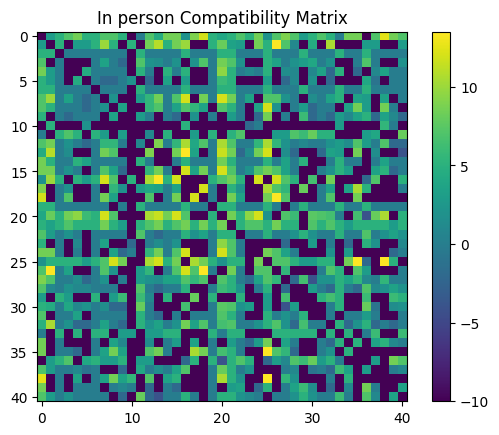

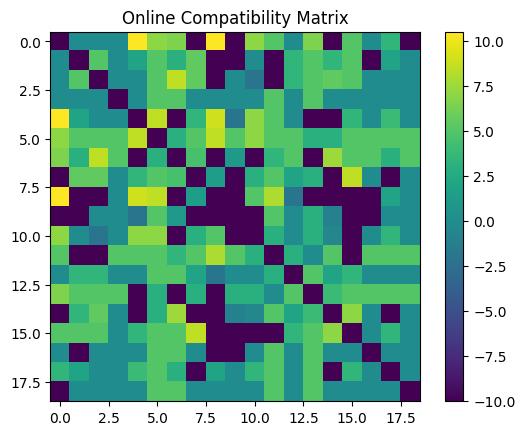

In [48]:
in_person_indices = all_participants.index[all_participants[attendance_mode_question] == "In-person"]
in_person_participants = all_participants.iloc[in_person_indices].reset_index()

online_indices = all_participants.index[all_participants[attendance_mode_question] == "Online"]
online_participants = all_participants.iloc[online_indices].reset_index()

in_person_compatibility_matrix = make_compatibility_matrix(in_person_participants)
img = in_person_compatibility_matrix
img[img < -1e2] = -10.0

plt.imshow(img)
plt.colorbar()
plt.title("In person Compatibility Matrix")
plt.show()


online_compatibility_matrix = make_compatibility_matrix(online_participants)
img = online_compatibility_matrix
img[img < -1e2] = -10.0

plt.imshow(img)
plt.colorbar()
plt.title("Online Compatibility Matrix")
plt.show()

Some utility functions to check what overlapping interests 2 people have

In [49]:

def wants_to_talk_about(person: pd.Series, question: str) -> bool:

    return person[question] in [options[2], options[3]] 

def check_interest_overlaps(person1: pd.Series, person2: pd.Series) -> typing.List[str]:

    overlaps = []

    for question in multiple_choice_questions:
        if wants_to_talk_about(person1, question) and wants_to_talk_about(person2, question):
            overlaps.append(question_tag_map[question])

    return overlaps


This makes matches by taking the highest score in the compatibility matrix, pairing those corresponding people, removing them from the pool of possible matches, and repeating until no possible matches remain.

This gives the "best" pairings based solely on the compatibility score that we have defined, but doesn't leave any room for any human input into the matches, e.g. based on people sharing a common interest, or if you know the people are already good friends. But the upside is it is totally automated.

In [50]:

def make_matches(dat: pd.DataFrame) -> typing.Tuple[typing.List[typing.List[int]], typing.List[float]]:

    matches = []
    scores = []

    compatibility_matrix = make_compatibility_matrix(dat)

    print(compatibility_matrix.shape)

    while len(matches) < m.floor(dat.shape[0] / 2.0):

        idx1, idx2 = np.unravel_index(compatibility_matrix.argmax(), compatibility_matrix.shape)

        matches.append([dat.iloc[idx1], dat.iloc[idx2]])
        scores.append(compatibility_matrix[idx1, idx2])

        ## now remove these people from matching pool
        compatibility_matrix[idx1, :] = -np.inf
        compatibility_matrix[:, idx1] = -np.inf
        compatibility_matrix[idx2, :] = -np.inf
        compatibility_matrix[:, idx2] = -np.inf 

    return matches, scores


## Uncomment to get the "best" matches, based purely on the compatibility score

# matches, scores = make_matches(in_person_participants)
# 
# for match, score in zip(matches, scores):
# 
#     print("")
#     print(f"  - {match[0]["Name"]}")
#     print(f"  - {match[1]["Name"]}")
# 
#     print(f"    score: {score}")
#     print(f"    overlaps: {check_interest_overlaps(match[0], match[1])}")
# 
#     print(f"    {[match[0][question] for question in multiple_choice_questions]}")
#     print(f"    {[match[1][question] for question in multiple_choice_questions]}")


This will take each participant and give you the top 3 possible matches for them. It will also tell you what areas of interest they share based on their answers to the multpile choice questions - e.g. if both want to talk about physics, hobbies, DEI etc. Then you can look at their responses to other questions to see if they have similar physics interests or hobbies and make matches based on that.

In [51]:

def make_possible_matches(dat: pd.DataFrame, n_options:int = 3) -> typing.Tuple[typing.List[typing.List[typing.Tuple[int, typing.List[int]]]], typing.List[typing.List[float]]]:

    matches = []
    scores = []

    compatibility_matrix = make_compatibility_matrix(dat)

    for index in range(dat.shape[0]):

        compatibilities = compatibility_matrix[index]
        good_matches = np.argsort(compatibilities)[-n_options:]

        matches.append((dat.iloc[index], [dat.iloc[match_idx] for match_idx in good_matches]))
        scores.append(compatibilities[good_matches])

    return matches, scores



# Matches for In-person Participants

In [52]:

matches, top_scores = make_possible_matches(in_person_participants)

for match, scores in sorted(zip(matches, top_scores), key = lambda x: x[1][-1]):

    print("")
    print(f"Possible matches for {match[0]["Name"]}")
    for other_person, score in zip(match[1][::-1], scores[::-1]):
        
        print(f"  - {other_person["Name"]:30s} :: score: {score} :: overlaps: {check_interest_overlaps(match[0], other_person)}")



Possible matches for person 4
  - person 55                      :: score: 5.0 :: overlaps: []
  - person 51                      :: score: 5.0 :: overlaps: []
  - person 2                       :: score: 5.0 :: overlaps: []

Possible matches for person 11
  - person 55                      :: score: 5.0 :: overlaps: []
  - person 51                      :: score: 5.0 :: overlaps: []
  - person 2                       :: score: 5.0 :: overlaps: []

Possible matches for person 29
  - person 55                      :: score: 5.0 :: overlaps: []
  - person 51                      :: score: 5.0 :: overlaps: []
  - person 2                       :: score: 5.0 :: overlaps: []

Possible matches for person 15
  - person 57                      :: score: 5.5 :: overlaps: ['physics', 'DEI']
  - person 2                       :: score: 5.0 :: overlaps: []
  - person 25                      :: score: 5.0 :: overlaps: []

Possible matches for person 10
  - person 30                      :: score: 

# Matches for Online participants

In [53]:

matches, top_scores = make_possible_matches(online_participants)

for match, scores in sorted(zip(matches, top_scores), key = lambda x: x[1][-1]):

    print("")
    print(f"Possible matches for {match[0]["Name"]}")
    for other_person, score in zip(match[1][::-1], scores[::-1]):
        
        print(f"  - {other_person["Name"]:30s} :: score: {score} :: overlaps: {check_interest_overlaps(match[0], other_person)}")


Possible matches for person 6
  - person 19                      :: score: 5.0 :: overlaps: []
  - person 39                      :: score: 5.0 :: overlaps: []
  - person 45                      :: score: 5.0 :: overlaps: []

Possible matches for person 26
  - person 39                      :: score: 5.0 :: overlaps: []
  - person 19                      :: score: 5.0 :: overlaps: []
  - person 45                      :: score: 3.0 :: overlaps: []

Possible matches for person 42
  - person 19                      :: score: 5.0 :: overlaps: []
  - person 21                      :: score: 5.0 :: overlaps: []
  - person 45                      :: score: 5.0 :: overlaps: []

Possible matches for person 48
  - person 19                      :: score: 5.0 :: overlaps: []
  - person 39                      :: score: 5.0 :: overlaps: []
  - person 45                      :: score: 5.0 :: overlaps: []

Possible matches for person 49
  - person 19                      :: score: 5.0 :: overlaps:

# Testing Matches

After you have put together matches based on info above and your own human thoughts and reasoning, you can check them here by putting matches into the "test1" and "test2" lists. This is a nice sanity check to make sure you haven't accidentally paired up two people that are not compatible - e.g. same institute, one is ECR and other wants non-ECR buddy etc.

In [54]:
test1 = [
    'person 37', 
    'person 59', 
    'person 54', 
]

test2 = [
    'person 35',
    'person 55',
    'person 10',
]

for p1, p2 in zip(test1, test2):

    p1_index = all_participants.index[all_participants['Name'] == p1][0]
    p2_index = all_participants.index[all_participants['Name'] == p2][0]

    person1 = all_participants.iloc[p1_index]
    person2 = all_participants.iloc[p2_index]
    print (f'{p1:30s} : {p2:30s} :: score = {compute_compatibility(person1, person2)}')


person 37                      : person 35                      :: score = 7.0
person 59                      : person 55                      :: score = 7.0
person 54                      : person 10                      :: score = -100002.0
